# 📊 Regressão Linear Múltipla — Price Prediction

Este notebook implementa uma solução completa de **regressão linear múltipla** usando o dataset `erolmasimov/price-prediction-multiple-linear-regression`.

**Etapas:**
1. Carregamento dos dados
2. Análise exploratória (EDA)
3. Pré-processamento
4. Treinamento do modelo
5. Avaliação e visualização dos resultados

## 1. Instalação e Importação de Dependências

In [1]:
# Instalar dependências (caso necessário)
# !pip install kagglehub[pandas-datasets] --quiet

import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Configurações visuais
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ Dependências carregadas com sucesso!')

✅ Dependências carregadas com sucesso!


## 2. Carregamento dos Dados

In [2]:
# Carregar o dataset via KaggleHub
file_path = "scrap price.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "erolmasimov/price-prediction-multiple-linear-regression",
    file_path,
)

print(f"Dataset carregado: {df.shape[0]} linhas × {df.shape[1]} colunas")
print("\nPrimeiros 5 registros:")
df.head()

Dataset carregado: 205 linhas × 26 colunas

Primeiros 5 registros:


,ID,symboling,name,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


## 3. Análise Exploratória (EDA)

In [3]:
# Informações gerais do dataset
print("=== Informações do Dataset ===")
df.info()

print("\n=== Estatísticas Descritivas ===")
df.describe()

=== Informações do Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   name              205 non-null    object 
 3   fueltypes         205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumbers       205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheels       205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize   

,ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [4]:
# Verificar valores ausentes
missing = df.isnull().sum()
print("=== Valores Ausentes por Coluna ===")
print(missing[missing > 0] if missing.sum() > 0 else "Nenhum valor ausente encontrado ✅")

=== Valores Ausentes por Coluna ===
Nenhum valor ausente encontrado ✅


Coluna alvo identificada: 'price'


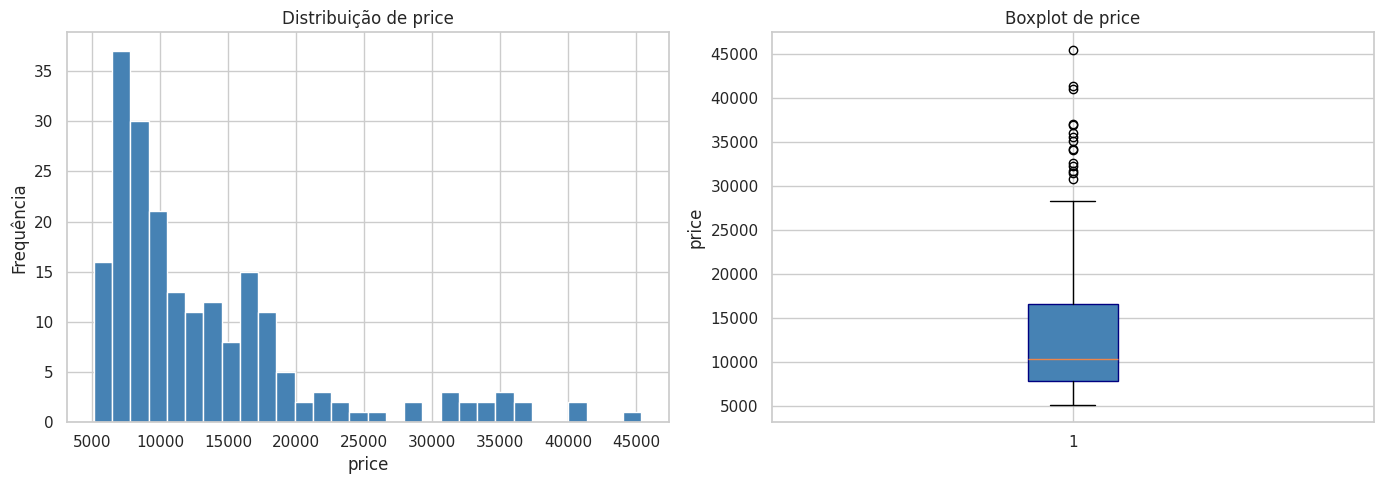

In [5]:
# Identificar a coluna alvo (target)
# Ajuste 'target_col' se necessário
target_col = df.columns[-1]  # Assumindo que a última coluna é o preço/target
print(f"Coluna alvo identificada: '{target_col}'")

# Distribuição da variável alvo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[target_col], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title(f'Distribuição de {target_col}')
axes[0].set_xlabel(target_col)
axes[0].set_ylabel('Frequência')

axes[1].boxplot(df[target_col].dropna(), patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title(f'Boxplot de {target_col}')
axes[1].set_ylabel(target_col)

plt.tight_layout()
plt.show()

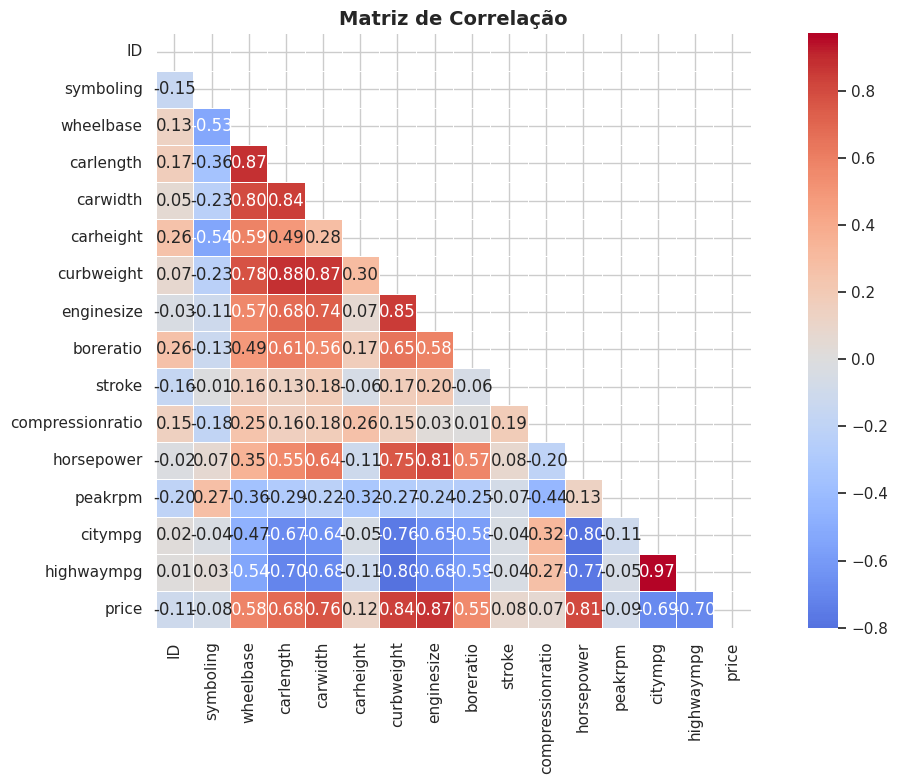


Correlação com 'price' (ordenada):
enginesize          0.874145
curbweight          0.835305
horsepower          0.808139
carwidth            0.759325
carlength           0.682920
wheelbase           0.577816
boreratio           0.553173
carheight           0.119336
stroke              0.079443
compressionratio    0.067984
symboling          -0.079978
peakrpm            -0.085267
ID                 -0.109093
citympg            -0.685751
highwaympg         -0.697599


In [6]:
# Matriz de correlação
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5, square=True
)
plt.title('Matriz de Correlação', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlação com a variável alvo
print(f"\nCorrelação com '{target_col}' (ordenada):")
print(corr_matrix[target_col].drop(target_col).sort_values(ascending=False).to_string())

## 4. Pré-processamento dos Dados

In [7]:
# Selecionar apenas colunas numéricas
df_model = numeric_df.copy()

# Remover linhas com valores ausentes
df_model.dropna(inplace=True)
print(f"Dataset após limpeza: {df_model.shape[0]} linhas × {df_model.shape[1]} colunas")

# Separar features (X) e target (y)
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

print(f"\nFeatures ({X.shape[1]}): {list(X.columns)}")
print(f"Target: '{target_col}'")

Dataset após limpeza: 205 linhas × 16 colunas

Features (15): ['ID', 'symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']
Target: 'price'


In [8]:
# Divisão treino / teste (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Treino:  {X_train.shape[0]} amostras")
print(f"Teste:   {X_test.shape[0]} amostras")

# Normalização (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\n✅ Dados normalizados com StandardScaler")

Treino:  164 amostras
Teste:   41 amostras

✅ Dados normalizados com StandardScaler


## 5. Treinamento do Modelo de Regressão Linear

In [9]:
# Treinar o modelo
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("✅ Modelo treinado com sucesso!")
print(f"\nIntercepto (β₀): {model.intercept_:.4f}")
print("\nCoeficientes:")
coef_df = pd.DataFrame({'Feature': X.columns, 'Coeficiente': model.coef_})
coef_df = coef_df.sort_values('Coeficiente', key=abs, ascending=False)
print(coef_df.to_string(index=False))

✅ Modelo treinado com sucesso!

Intercepto (β₀): 13223.4146

Coeficientes:
         Feature  Coeficiente
      enginesize  4556.052177
         citympg -2399.493671
compressionratio  1381.877504
      highwaympg  1345.615437
      horsepower  1158.695570
         peakrpm  1134.314246
          stroke -1035.576125
        carwidth  1011.973635
              ID  -760.365839
       wheelbase   693.337913
       carlength  -650.675996
       carheight   625.717746
      curbweight   342.176442
       symboling   282.690422
       boreratio   137.383360


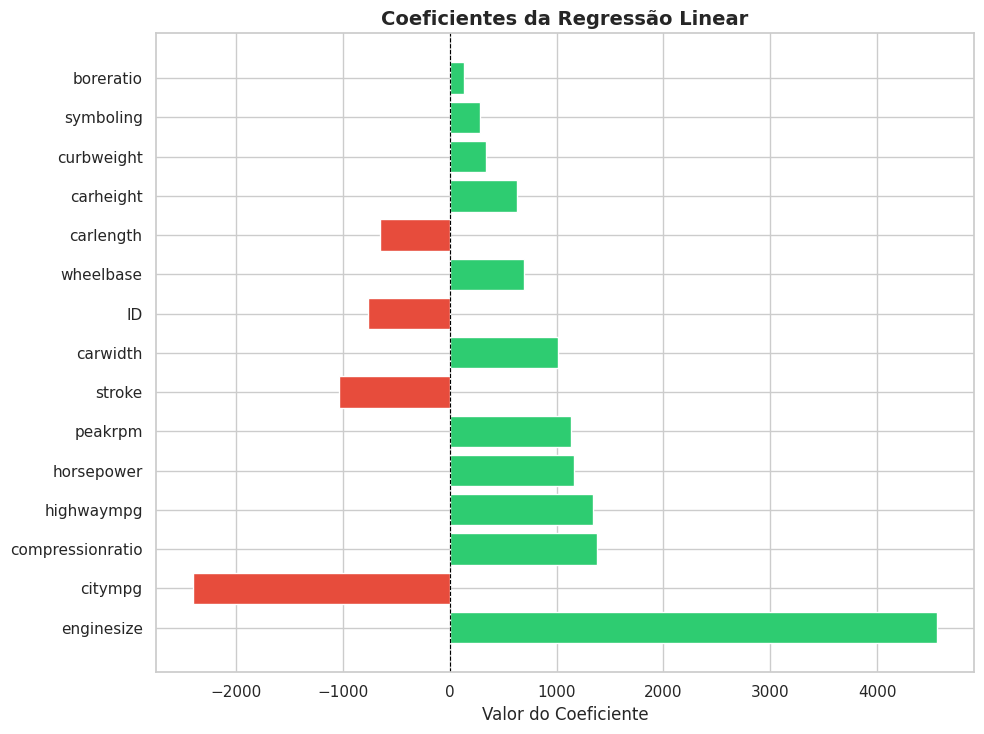

In [10]:
# Visualizar importância dos coeficientes
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coeficiente']]

plt.figure(figsize=(10, max(4, len(coef_df) * 0.5)))
plt.barh(coef_df['Feature'], coef_df['Coeficiente'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Valor do Coeficiente')
plt.title('Coeficientes da Regressão Linear', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Avaliação do Modelo

In [11]:
# Predições
y_pred_train = model.predict(X_train_scaled)
y_pred_test  = model.predict(X_test_scaled)

# Métricas
def print_metrics(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"  MAE  (Erro Médio Absoluto):     {mae:.4f}")
    print(f"  RMSE (Raiz do Erro Quadrático): {rmse:.4f}")
    print(f"  R²   (Coeficiente de Determ.):  {r2:.4f}")
    return {'MAE': mae, 'RMSE': rmse, 'R²': r2}

metrics_train = print_metrics(y_train, y_pred_train, 'Conjunto de Treino')
print()
metrics_test  = print_metrics(y_test, y_pred_test,  'Conjunto de Teste')

--- Conjunto de Treino ---
  MAE  (Erro Médio Absoluto):     2146.5093
  RMSE (Raiz do Erro Quadrático): 2836.3134
  R²   (Coeficiente de Determ.):  0.8651

--- Conjunto de Teste ---
  MAE  (Erro Médio Absoluto):     2411.0940
  RMSE (Raiz do Erro Quadrático): 3422.0031
  R²   (Coeficiente de Determ.):  0.8517


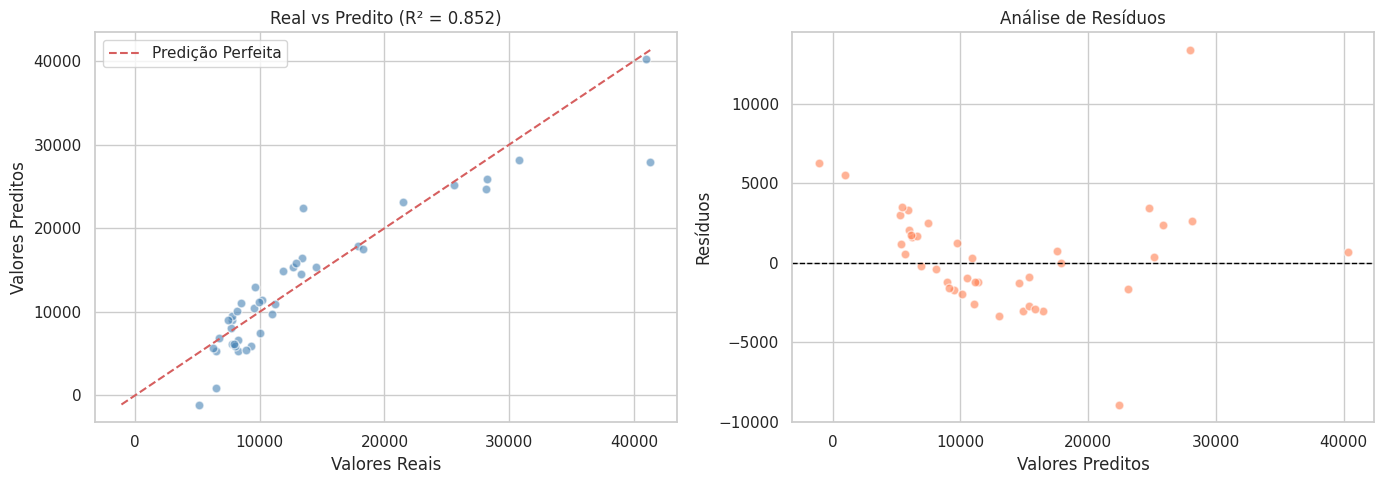

In [12]:
# Gráfico: Valores Reais vs Preditos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Real vs Predito
axes[0].scatter(y_test, y_pred_test, alpha=0.6, color='steelblue', edgecolors='white', s=40)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Predição Perfeita')
axes[0].set_xlabel('Valores Reais')
axes[0].set_ylabel('Valores Preditos')
axes[0].set_title(f'Real vs Predito (R² = {metrics_test["R²"]:.3f})')
axes[0].legend()

# Resíduos
residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.6, color='coral', edgecolors='white', s=40)
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_xlabel('Valores Preditos')
axes[1].set_ylabel('Resíduos')
axes[1].set_title('Análise de Resíduos')

plt.tight_layout()
plt.show()

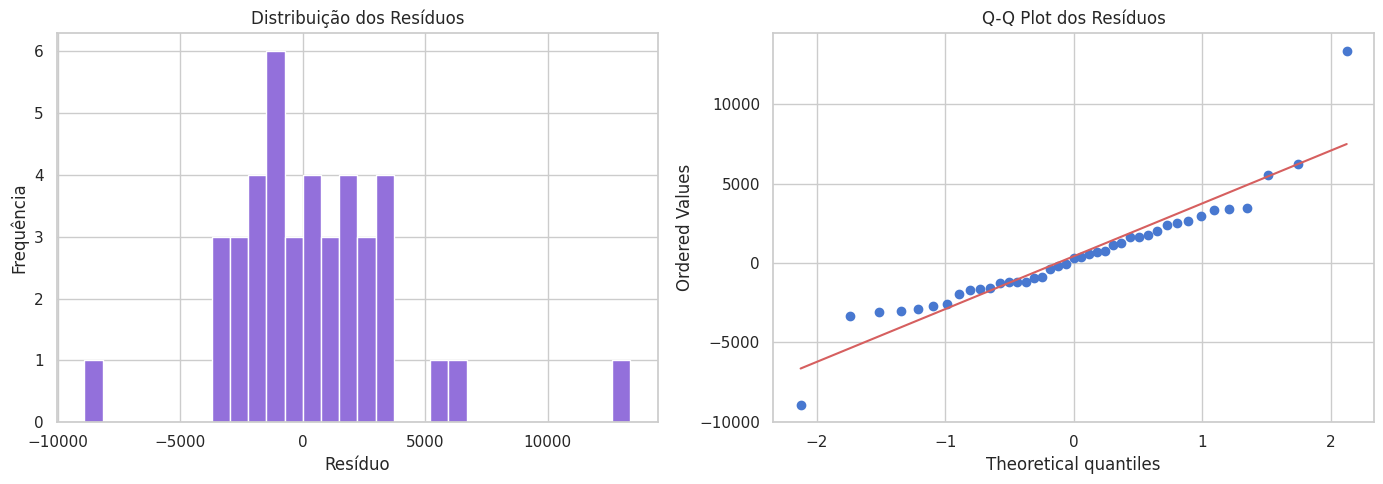

In [13]:
# Distribuição dos resíduos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals, bins=30, color='mediumpurple', edgecolor='white')
axes[0].set_title('Distribuição dos Resíduos')
axes[0].set_xlabel('Resíduo')
axes[0].set_ylabel('Frequência')

import scipy.stats as stats
stats.probplot(residuals, plot=axes[1])
axes[1].set_title('Q-Q Plot dos Resíduos')

plt.tight_layout()
plt.show()

## 7. Resumo dos Resultados

In [14]:
summary = pd.DataFrame({
    'Métrica': ['MAE', 'RMSE', 'R²'],
    'Treino': [metrics_train['MAE'], metrics_train['RMSE'], metrics_train['R²']],
    'Teste':  [metrics_test['MAE'],  metrics_test['RMSE'],  metrics_test['R²']]
})

print("=" * 45)
print("       RESUMO DAS MÉTRICAS DO MODELO")
print("=" * 45)
print(summary.to_string(index=False))
print("=" * 45)

r2 = metrics_test['R²']
if r2 >= 0.9:
    nivel = "🏆 Excelente"
elif r2 >= 0.75:
    nivel = "✅ Bom"
elif r2 >= 0.5:
    nivel = "⚠️ Moderado"
else:
    nivel = "❌ Fraco"

print(f"\nDesempenho Geral: {nivel} (R² Teste = {r2:.4f})")

       RESUMO DAS MÉTRICAS DO MODELO
Métrica      Treino       Teste
    MAE 2146.509292 2411.093962
   RMSE 2836.313408 3422.003080
     R²    0.865108    0.851666

Desempenho Geral: ✅ Bom (R² Teste = 0.8517)
